In [ ]:
import yfinance as yf

In [ ]:
ticker_symbols = 'MC.PA RMS.PA KER.PA RACE.MI CFR.SW ^FCHI ^VIX'


df_hist = yf.download(
    tickers=ticker_symbols, 
    start="2018-01-01", 
    end="2026-03-25", 
    interval="1d",
    auto_adjust=False,
)


[*********************100%***********************]  7 of 7 completed


In [78]:
df_hist.head()

Price       Adj Close                                                 \
Ticker         CFR.SW      KER.PA       MC.PA    RACE.MI      RMS.PA   
Date                                                                   
2018-01-02        NaN  295.965210  210.943344  82.545799  410.125092   
2018-01-03  73.714989  299.436310  212.210938  83.964119  411.985016   
2018-01-04  73.797546  307.304047  214.702393  87.462624  412.729004   
2018-01-05  73.913094  309.926575  218.111755  88.266327  416.169952   
2018-01-08  74.078201  306.378418  214.614975  89.495537  416.541962   

Price                              Close                          ...  \
Ticker            ^FCHI  ^VIX     CFR.SW      KER.PA       MC.PA  ...   
Date                                                              ...   
2018-01-02  5288.600098  9.77        NaN  356.627686  241.300003  ...   
2018-01-03  5331.279785  9.15  89.300003  360.810181  242.750000  ...   
2018-01-04  5413.689941  9.22  89.400002  370.290497  245.600006  ...   
2018-01-05  5470.750000  9.22  89.540001  373.450623  249.500000  ...   
2018-01-08  5487.419922  9.52  89.739998  369.175171  245.500000  ...   

Price             Open                         Volume                      \
Ticker          RMS.PA        ^FCHI   ^VIX     CFR.SW    KER.PA     MC.PA   
Date                                                                        
2018-01-02  445.799988  5318.740234  10.95        NaN  169054.0  631294.0   
2018-01-03  442.000000  5295.310059   9.56  1468136.0  193951.0  521585.0   
2018-01-04  444.600006  5360.009766   9.01  1686468.0  273096.0  611052.0   
2018-01-05  443.399994  5424.160156   9.10  4560165.0  179250.0  454725.0   
2018-01-08  447.799988  5483.470215   9.61  1770245.0  167998.0  536733.0   

Price                                            
Ticker        RACE.MI   RMS.PA       ^FCHI ^VIX  
Date                                             
2018-01-02   511258.0  36036.0  66802600.0  0.0  
2018-01-03   427199.0  24416.0  75371700.0  0.0  
2018-01-04  1056023.0  39774.0  92583500.0  0.0  
2018-01-05   587577.0  40301.0  76275800.0  0.0  
2018-01-08   578255.0  37191.0  72318000.0  0.0  

[5 rows x 42 columns]

In [79]:
df_hist.to_csv("yahoo_finance_adjusted.csv")

In [ ]:
df_hist.size

89292

In [15]:
import pandas as pd
import numpy as np

# On saute les 2 premières lignes (Price et Ticker) pour tomber directement sur les données
df = pd.read_csv('yahoo_finance_adjusted.csv', skiprows=2)

# On renomme les colonnes manuellement car Yahoo exporte des noms complexes
# L'ordre correspond à ton fichier : CFR.SW, KER.PA, MC.PA, RACE.MI, RMS.PA, ^FCHI, ^VIX
df.columns = ['Date', 'RICHEMONT', 'KERING', 'LVMH', 'FERRARI', 'HERMES', 'CAC40', 'VIX'] + list(df.columns[8:])

# On ne garde que les 8 premières colonnes qui nous intéressent
df = df[['Date', 'RICHEMONT', 'KERING', 'LVMH', 'FERRARI', 'HERMES', 'CAC40', 'VIX']].copy()

# On convertit la date et on enlève les lignes vides
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])

# Sauvegarde du fichier propre
df.to_csv('yahoo_finance_clean.csv', index=False)

print("Fichier nettoyé avec succès !")
df.head()

Fichier nettoyé avec succès !


,Date,RICHEMONT,KERING,LVMH,FERRARI,HERMES,CAC40,VIX
0,2018-01-02,NaN,295.965210,210.943344,82.545799,410.125092,5288.600098,9.77
1,2018-01-03,73.714989,299.436310,212.210938,83.964119,411.985016,5331.279785,9.15
2,2018-01-04,73.797546,307.304047,214.702393,87.462624,412.729004,5413.689941,9.22
3,2018-01-05,73.913094,309.926575,218.111755,88.266327,416.169952,5470.750000,9.22
4,2018-01-08,74.078201,306.378418,214.614975,89.495537,416.541962,5487.419922,9.52


In [21]:
import pandas as pd


df = pd.read_csv('yahoo_finance_adjusted.csv', header=[0, 1], index_col=0)


mapping = {
    'CFR.SW': 'RICHEMONT',
    'KER.PA': 'KERING',
    'MC.PA': 'LVMH',
    'RACE.MI': 'FERRARI',
    'RMS.PA': 'HERMES',
    '^FCHI': 'CAC40',
    '^VIX': 'VIX'
}


df.columns = df.columns.set_levels(
    [mapping.get(col, col) for col in df.columns.levels[1]], 
    level=1
)


df.to_csv('luxe_complet_nomme.csv')



df.head()

Price,Adj Close,Adj Close.1,Adj Close.2,Adj Close.3,Adj Close.4,Adj Close.5,Adj Close.6,Close,Close.1,Close.2,...,Open.4,Open.5,Open.6,Volume,Volume.1,Volume.2,Volume.3,Volume.4,Volume.5,Volume.6
Ticker,RICHEMONT,KERING,LVMH,FERRARI,HERMES,CAC40,VIX,RICHEMONT,KERING,LVMH,...,HERMES,CAC40,VIX,RICHEMONT,KERING,LVMH,FERRARI,HERMES,CAC40,VIX
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,NaN,295.965210,210.943344,82.545799,410.125092,5288.600098,9.77,NaN,356.627686,241.300003,...,445.799988,5318.740234,10.95,NaN,169054.0,631294.0,511258.0,36036.0,66802600.0,0.0
2018-01-03,73.714989,299.436310,212.210938,83.964119,411.985016,5331.279785,9.15,89.300003,360.810181,242.750000,...,442.000000,5295.310059,9.56,1468136.0,193951.0,521585.0,427199.0,24416.0,75371700.0,0.0
2018-01-04,73.797546,307.304047,214.702393,87.462624,412.729004,5413.689941,9.22,89.400002,370.290497,245.600006,...,444.600006,5360.009766,9.01,1686468.0,273096.0,611052.0,1056023.0,39774.0,92583500.0,0.0
2018-01-05,73.913094,309.926575,218.111755,88.266327,416.169952,5470.750000,9.22,89.540001,373.450623,249.500000,...,443.399994,5424.160156,9.10,4560165.0,179250.0,454725.0,587577.0,40301.0,76275800.0,0.0
2018-01-08,74.078201,306.378418,214.614975,89.495537,416.541962,5487.419922,9.52,89.739998,369.175171,245.500000,...,447.799988,5483.470215,9.61,1770245.0,167998.0,536733.0,578255.0,37191.0,72318000.0,0.0


In [22]:
import numpy as np 

In [23]:
df_adj = df['Adj Close'].copy()

In [24]:
df_returns = np.log(df_adj / df_adj.shift(1))

In [25]:
df_returns = df_returns.dropna()

In [26]:
df_returns.head()

Ticker,RICHEMONT
Date,
2018-01-04,0.001119
2018-01-05,0.001565
2018-01-08,0.002231
2018-01-09,0.001336
2018-01-10,-0.008494


In [27]:
# Affiche les 5 premières lignes et TOUTES les colonnes
print(df_returns.columns) # Pour lister les noms et vérifier qu'ils sont là
df_returns.head()


Index(['RICHEMONT'], dtype='str', name='Ticker')


Ticker,RICHEMONT
Date,
2018-01-04,0.001119
2018-01-05,0.001565
2018-01-08,0.002231
2018-01-09,0.001336
2018-01-10,-0.008494


In [29]:
import pandas as pd
import numpy as np

# 1. On charge sans fioritures pour voir ce qu'il y a dedans
# On essaie de détecter le séparateur automatiquement
df_raw = pd.read_csv('yahoo_finance_adjusted.csv', sep=None, engine='python')

# 2. On extrait uniquement les colonnes de prix (on saute les headers de Yahoo)
# On part de la ligne 2 pour avoir les vraies données
df_clean = pd.read_csv('yahoo_finance_adjusted.csv', skiprows=2)

# 3. On renomme les 8 premières colonnes (Date + tes 7 actifs)
# On force le nom car c'est là que ça bloquait
noms_colonnes = ['Date', 'RICHEMONT', 'KERING', 'LVMH', 'FERRARI', 'HERMES', 'CAC40', 'VIX']
df_clean.columns = noms_colonnes + list(df_clean.columns[len(noms_colonnes):])

# 4. On ne garde que ce qui nous intéresse
df_final = df_clean[['Date', 'RICHEMONT', 'KERING', 'LVMH', 'FERRARI', 'HERMES', 'CAC40', 'VIX']].copy()

# 5. Conversion en Date et calcul des Rendements (Semaine 2 : Stationnarité)
df_final['Date'] = pd.to_datetime(df_final['Date'])
df_final = df_final.set_index('Date')

# Calcul des rendements log
df_returns = np.log(df_final / df_final.shift(1)).dropna()

print("Succès ! Voici tes colonnes :", df_returns.columns.tolist())
df_returns.head()

Succès ! Voici tes colonnes : ['RICHEMONT', 'KERING', 'LVMH', 'FERRARI', 'HERMES', 'CAC40', 'VIX']


,RICHEMONT,KERING,LVMH,FERRARI,HERMES,CAC40,VIX
Date,,,,,,,
2018-01-04,0.001119,0.025936,0.011672,0.040822,0.001804,0.015340,0.007621
2018-01-05,0.001565,0.008498,0.015755,0.009147,0.008303,0.010485,0.000000
2018-01-08,0.002231,-0.011514,-0.016162,0.013830,0.000893,0.003042,0.032020
2018-01-09,0.001336,0.015489,0.002441,0.013120,0.002230,0.006633,0.057158
2018-01-10,-0.008494,0.022308,-0.016801,-0.002610,0.001781,-0.003493,-0.026132


In [30]:
df_returns.head()


,RICHEMONT,KERING,LVMH,FERRARI,HERMES,CAC40,VIX
Date,,,,,,,
2018-01-04,0.001119,0.025936,0.011672,0.040822,0.001804,0.015340,0.007621
2018-01-05,0.001565,0.008498,0.015755,0.009147,0.008303,0.010485,0.000000
2018-01-08,0.002231,-0.011514,-0.016162,0.013830,0.000893,0.003042,0.032020
2018-01-09,0.001336,0.015489,0.002441,0.013120,0.002230,0.006633,0.057158
2018-01-10,-0.008494,0.022308,-0.016801,-0.002610,0.001781,-0.003493,-0.026132


In [31]:

df_returns.to_csv('rendements_luxe_final.csv')


In [2]:
import pandas as pd
import numpy as np

# 1. On recharge et on nettoie (au cas où la mémoire a été vidée)
df_clean = pd.read_csv('yahoo_finance_adjusted.csv', skiprows=2)
noms_colonnes = ['Date', 'RICHEMONT', 'KERING', 'LVMH', 'FERRARI', 'HERMES', 'CAC40', 'VIX']
df_clean.columns = noms_colonnes + list(df_clean.columns[len(noms_colonnes):])
df_final = df_clean[['Date', 'RICHEMONT', 'KERING', 'LVMH', 'FERRARI', 'HERMES', 'CAC40', 'VIX']].copy()
df_final['Date'] = pd.to_datetime(df_final['Date'])
df_final = df_final.set_index('Date')

# 2. On recrée df_returns (Stationnarité - Semaine 2)
df_returns = np.log(df_final / df_final.shift(1)).dropna()

# 3. MAINTENANT tu peux générer tes stats (Semaine 3)
stats_table = df_returns.describe()
stats_table.loc['skew'] = df_returns.skew()
stats_table.loc['kurtosis'] = df_returns.kurtosis()

print("Statistiques générées avec succès !")
print(stats_table)

Statistiques générées avec succès !
            RICHEMONT       KERING         LVMH      FERRARI       HERMES  \
count     1891.000000  1891.000000  1891.000000  1891.000000  1891.000000   
mean         0.000449    -0.000044     0.000593     0.000613     0.000738   
std          0.020289     0.021976     0.018680     0.018119     0.016647   
min         -0.145032    -0.131416    -0.090777    -0.167380    -0.067652   
25%         -0.010049    -0.011474    -0.009336    -0.008405    -0.007825   
50%          0.000696     0.000193     0.000801     0.000653     0.001533   
75%          0.010928     0.011544     0.010065     0.010604     0.009888   
max          0.151527     0.111207     0.120552     0.104542     0.087134   
skew         0.065301    -0.154662     0.253880    -0.493333    -0.037188   
kurtosis     7.277542     3.873071     4.199411     8.983435     2.812608   

                CAC40          VIX  
count     1891.000000  1891.000000  
mean         0.000312    -0.001199  
std  

In [3]:
stats_table.to_csv('stats_descriptives_luxe.csv')

In [5]:
%pip install matplotlib seaborn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --------------- ------------------------ 3.1/8.3 MB 14.8 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 16.2 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 14.7 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 12.7 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   -------------------------- ------------- 1.6/2.3 MB 7.3 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 6.7 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ----------- ---------------------------- 2.1/7.2 MB 9.8 MB/s eta 0:00:01
   ------------------------ --------------- 4.5/7.2 MB 10.3 MB/s eta 0:00:01
   ------------------------------------- -- 6.8/7.2 MB 10.9 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 9.7 MB/s  0:00:00

   --------------------------------

Matplotlib is building the font cache; this may take a moment.


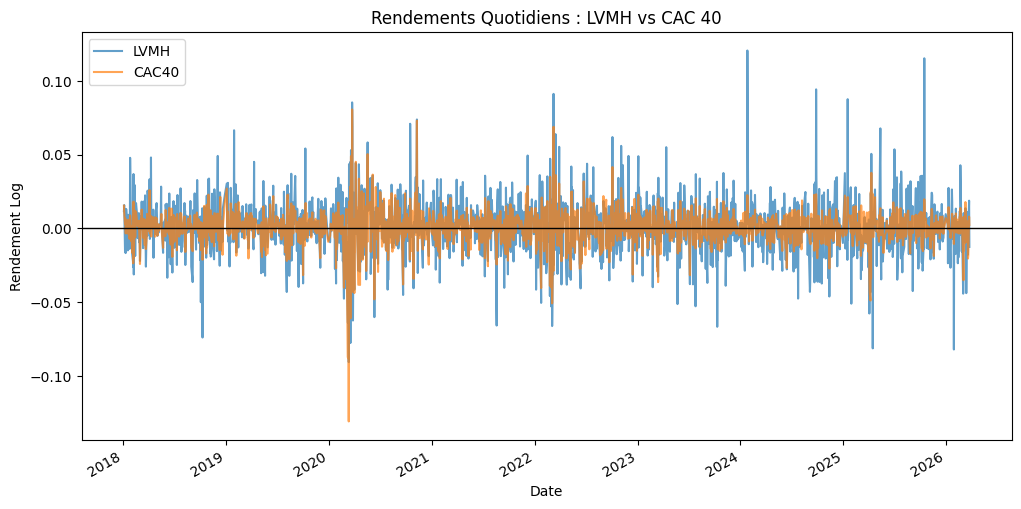

In [6]:
import matplotlib.pyplot as plt

# On trace les rendements de LVMH et du CAC40 pour comparer
df_returns[['LVMH', 'CAC40']].plot(figsize=(12, 6), alpha=0.7)
plt.title("Rendements Quotidiens : LVMH vs CAC 40")
plt.ylabel("Rendement Log")
plt.axhline(0, color='black', linewidth=1) # Ligne du zéro
plt.legend()
plt.show()

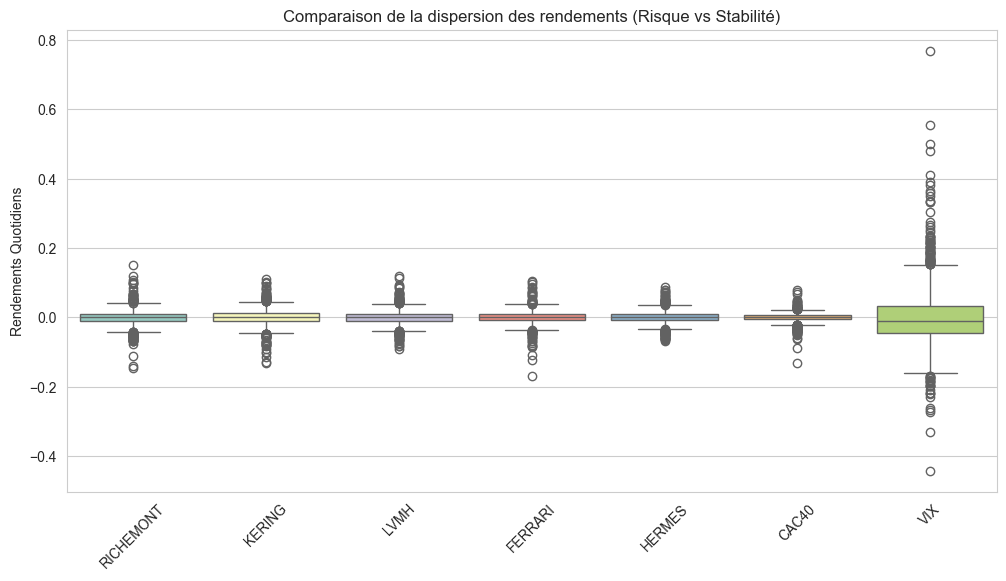

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
# On utilise un style épuré
sns.set_style("whitegrid")

# Création du boxplot pour toutes les colonnes
sns.boxplot(data=df_returns, palette="Set3")

plt.title("Comparaison de la dispersion des rendements (Risque vs Stabilité)")
plt.ylabel("Rendements Quotidiens")
plt.xticks(rotation=45) # Pour bien lire les noms des entreprises
plt.show()


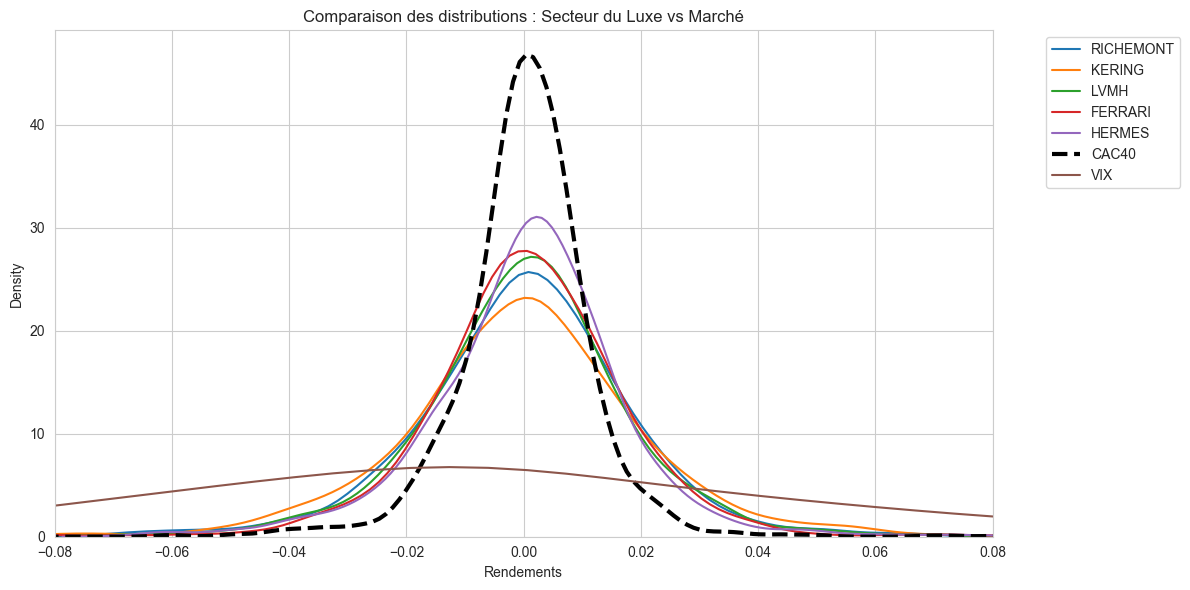

In [8]:
plt.figure(figsize=(12, 6))

for col in df_returns.columns:
    if col == 'CAC40':
        # On met le CAC40 en noir et plus épais pour qu'il serve de référence
        sns.kdeplot(df_returns[col], label=col, color='black', linewidth=3, linestyle='--')
    else:
        sns.kdeplot(df_returns[col], label=col, linewidth=1.5)

plt.title("Comparaison des distributions : Secteur du Luxe vs Marché")
plt.xlabel("Rendements")
plt.xlim(-0.08, 0.08) # On resserre pour éviter de voir trop de vide sur les côtés
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # On sort la légende pour pas cacher le graph
plt.tight_layout()
plt.show()

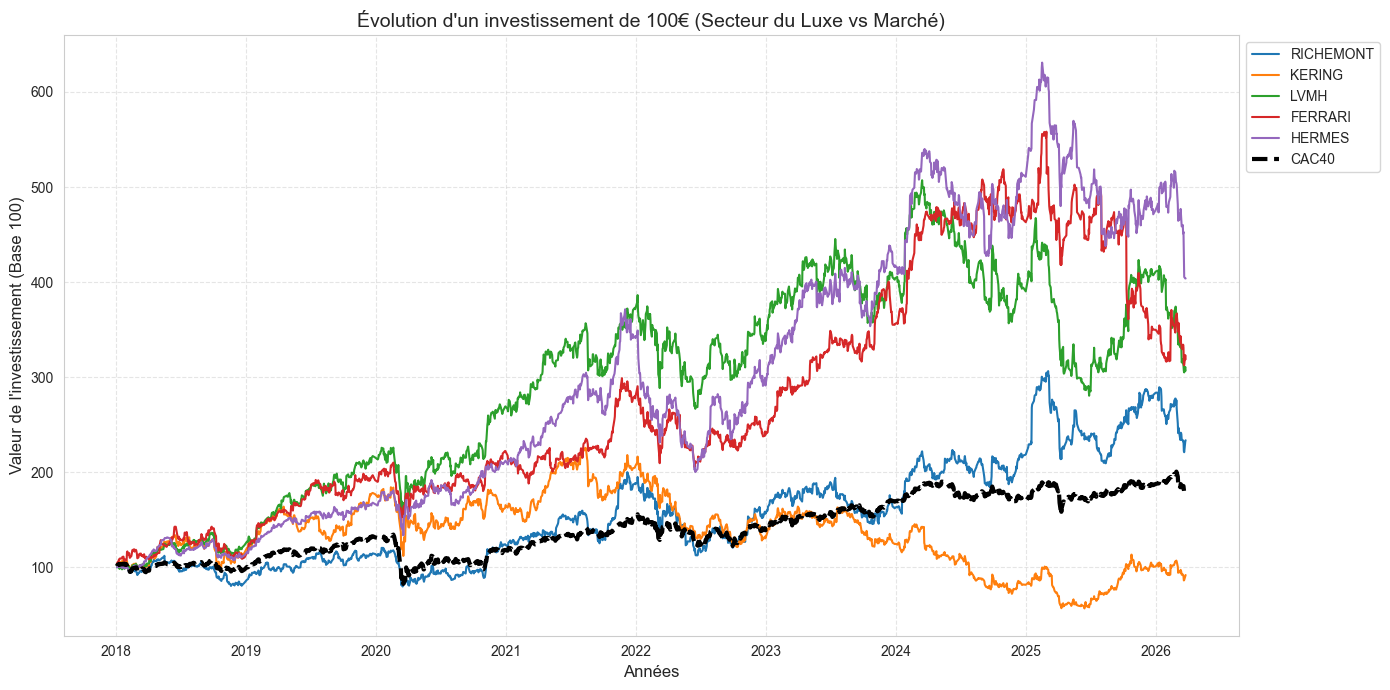

In [9]:
import matplotlib.pyplot as plt

# 1. Calcul de la performance cumulée (Base 100)
# On part des rendements log et on remonte aux prix relatifs
df_cum_perf = np.exp(df_returns.cumsum()) * 100

# 2. Création du graphique
plt.figure(figsize=(14, 7))

# On trace chaque entreprise
for col in df_cum_perf.columns:
    if col == 'CAC40':
        plt.plot(df_cum_perf.index, df_cum_perf[col], label=col, color='black', linewidth=3, linestyle='--')
    elif col == 'VIX':
        continue # On n'affiche pas le VIX ici car il n'est pas sur la même échelle
    else:
        plt.plot(df_cum_perf.index, df_cum_perf[col], label=col, linewidth=1.5)

plt.title("Évolution d'un investissement de 100€ (Secteur du Luxe vs Marché)", fontsize=14)
plt.xlabel("Années", fontsize=12)
plt.ylabel("Valeur de l'investissement (Base 100)", fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

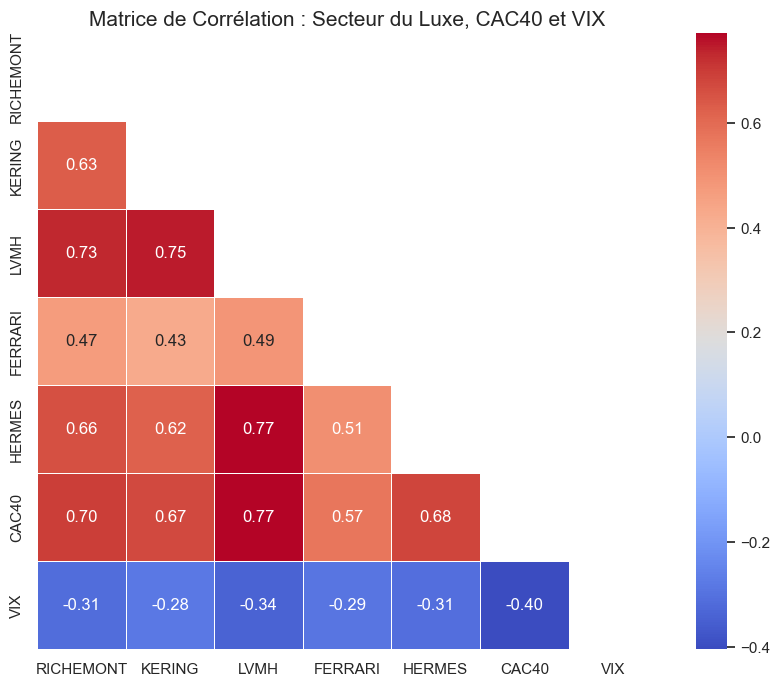

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcul de la matrice sur les rendements (très important !)
corr_matrix = df_returns.corr()

# 2. Configuration du graphique
plt.figure(figsize=(10, 8))
sns.set(style="white")

# 3. Création de la Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Pour ne pas afficher le triangle du haut (doublons)
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True,      # Affiche les chiffres dans les cases
            cmap='coolwarm', # Bleu = négatif, Rouge = positif
            fmt=".2f",       # 2 chiffres après la virgule
            linewidths=.5)

plt.title("Matrice de Corrélation : Secteur du Luxe, CAC40 et VIX", fontsize=15)
plt.show()

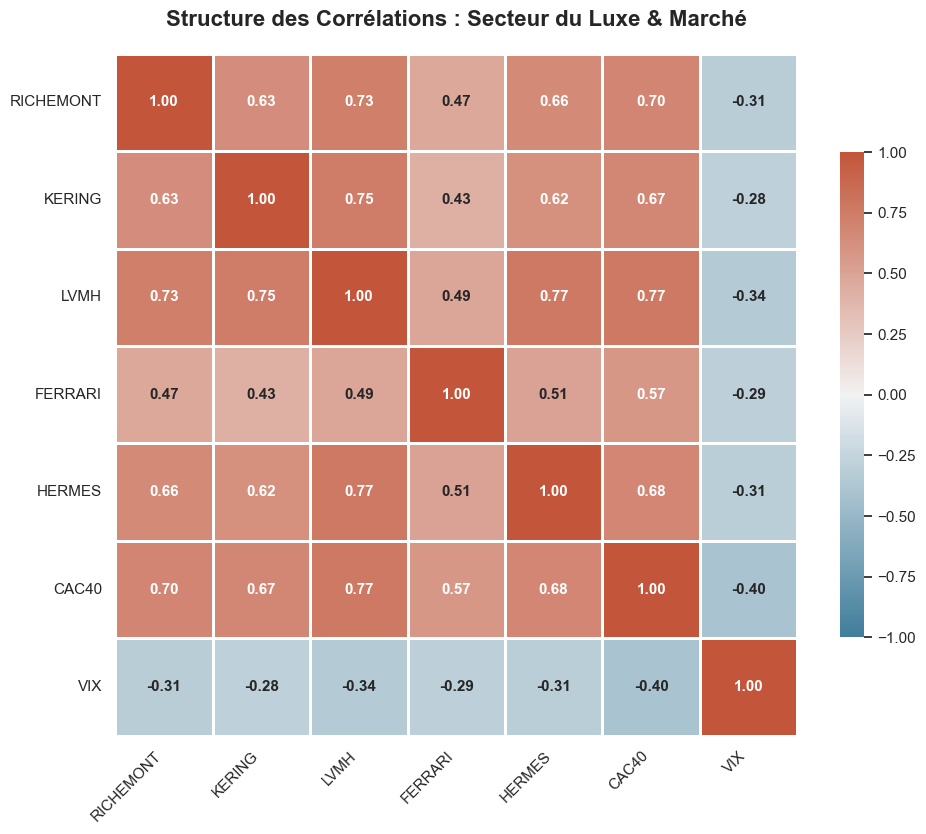

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# On change le style global pour quelque chose de plus "clean"
plt.figure(figsize=(11, 9))
sns.set_theme(style="white")

# Palette de couleurs pro (du bleu profond au rouge bordeaux)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# On dessine la heatmap avec des réglages précis
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap=cmap, 
            vmax=1, vmin=-1, center=0,
            square=True, 
            linewidths=.8, 
            cbar_kws={"shrink": .7}, # Barre de légende plus fine
            annot_kws={"size": 11, "weight": "bold"}) # Chiffres plus lisibles

plt.title("Structure des Corrélations : Secteur du Luxe & Marché", 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

In [12]:
# On arrondit à 3 décimales pour la précision académique
matrice_formelle = df_returns.corr().round(3)

# On affiche simplement
matrice_formelle

,RICHEMONT,KERING,LVMH,FERRARI,HERMES,CAC40,VIX
RICHEMONT,1.000,0.633,0.732,0.469,0.658,0.695,-0.313
KERING,0.633,1.000,0.745,0.425,0.621,0.675,-0.283
LVMH,0.732,0.745,1.000,0.487,0.768,0.771,-0.340
FERRARI,0.469,0.425,0.487,1.000,0.506,0.571,-0.293
HERMES,0.658,0.621,0.768,0.506,1.000,0.683,-0.309
CAC40,0.695,0.675,0.771,0.571,0.683,1.000,-0.404
VIX,-0.313,-0.283,-0.340,-0.293,-0.309,-0.404,1.000


In [13]:
matrice_formelle.to_csv('matrice_correlation_formelle.csv')

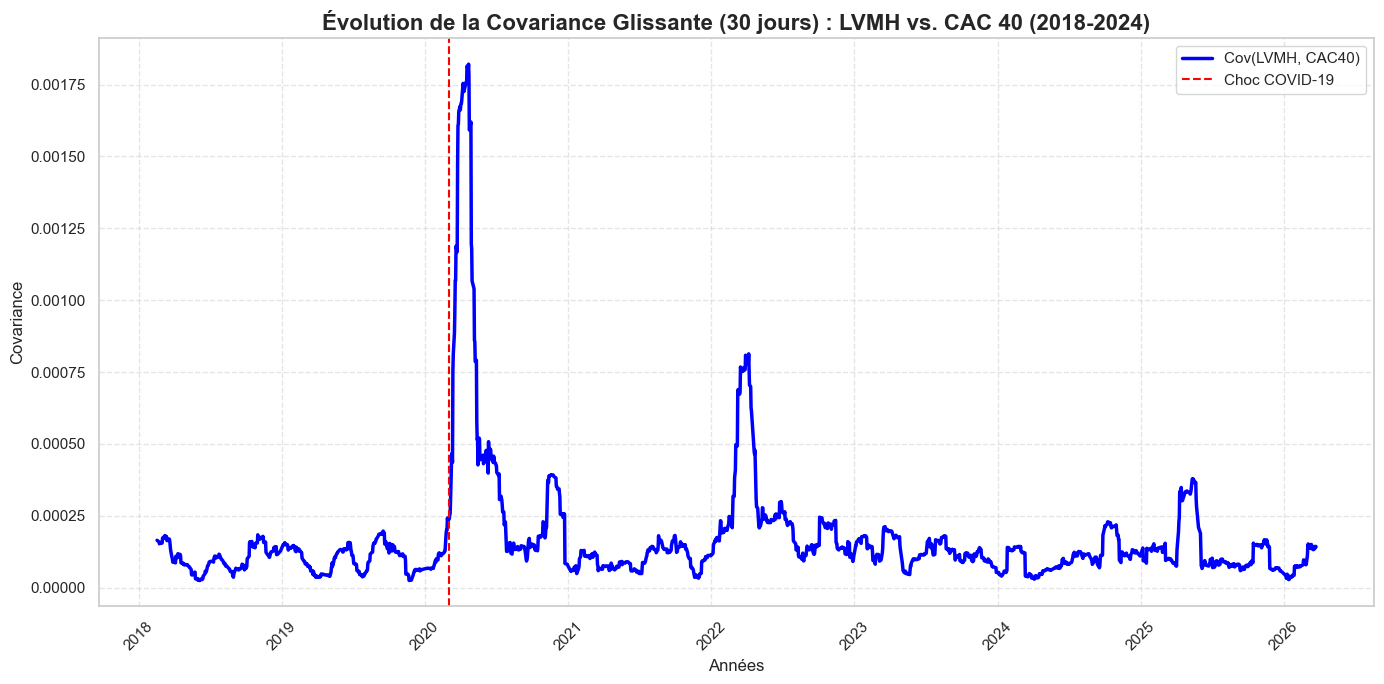

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# On s'assure d'avoir bien tes rendements (nettoyage de données - Semaine 2)
# (Inutile si df_returns existe déjà)

# 1. Calcul de la covariance glissante (fenêtre de 30 jours de bourse, environ 1.5 mois)
rolling_cov = df_returns['LVMH'].rolling(window=30).cov(df_returns['CAC40']).dropna()

# 2. Création du graphique pro pour ton mémoire
plt.figure(figsize=(14, 7))
sns.set(style="whitegrid")

# Trace de la ligne principale
plt.plot(rolling_cov.index, rolling_cov.values, color='blue', linewidth=2.5, label='Cov(LVMH, CAC40)')

# Zone COVID-19 (L'exemple du choc systémique)
plt.axvline(pd.to_datetime('2020-03-01'), color='red', linestyle='--', linewidth=1.5, label='Choc COVID-19')

# Réglages des axes et titres
plt.title("Évolution de la Covariance Glissante (30 jours) : LVMH vs. CAC 40 (2018-2024)", fontsize=16, fontweight='bold')
plt.ylabel("Covariance", fontsize=12)
plt.xlabel("Années", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Pour s'assurer que l'axe des années est bien formaté
import matplotlib.dates as mdates
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

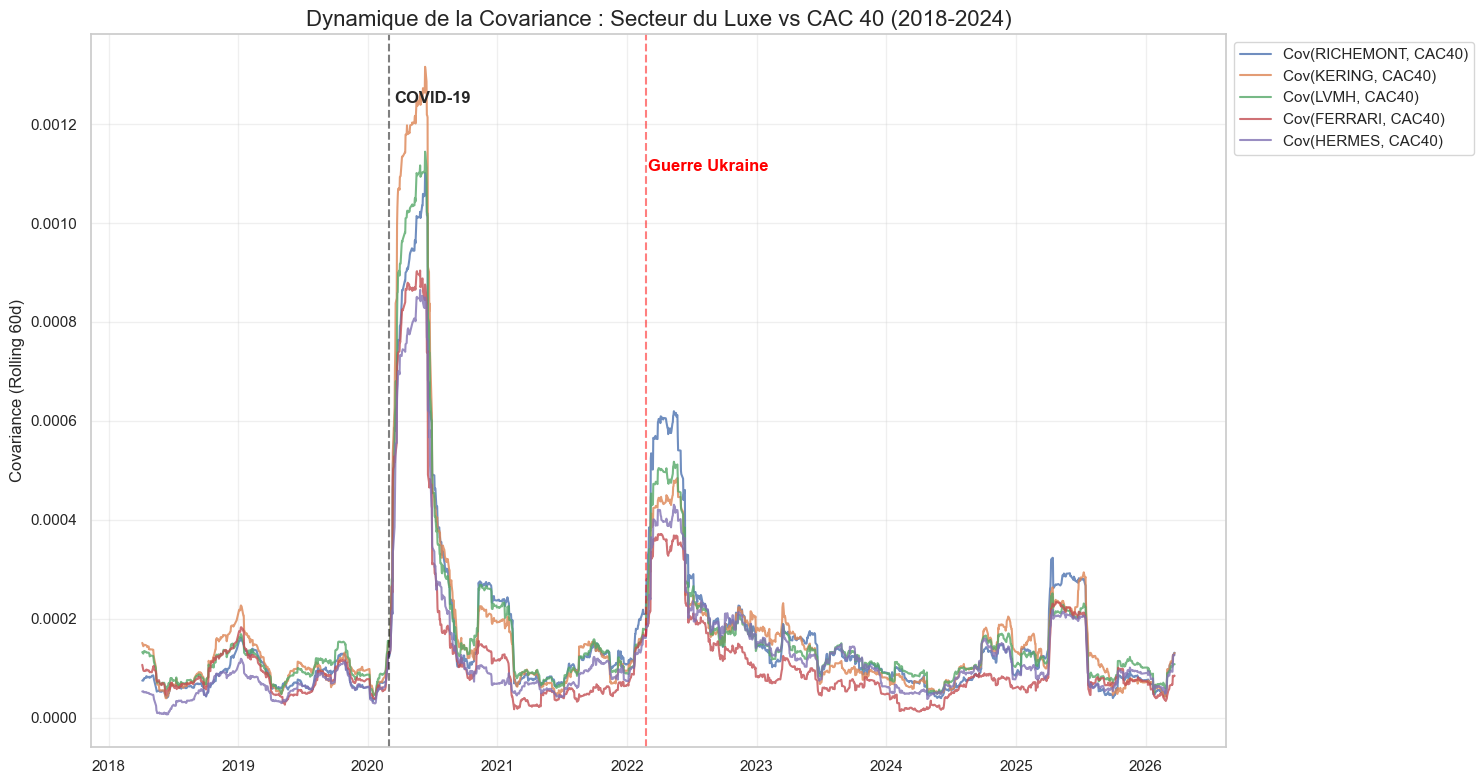

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(15, 8))

# On boucle sur chaque entreprise (sauf le CAC40 et le VIX)
entreprises = [c for c in df_returns.columns if c not in ['CAC40', 'VIX']]

for ent in entreprises:
    # Calcul de la covariance glissante sur 60 jours (plus lissé, plus "pro")
    rolling_cov = df_returns[ent].rolling(window=60).cov(df_returns['CAC40'])
    plt.plot(rolling_cov.index, rolling_cov, label=f'Cov({ent}, CAC40)', alpha=0.8)

# Ajout des dates clés pour ton analyse
plt.axvline(pd.to_datetime('2020-03-01'), color='black', linestyle='--', alpha=0.5)
plt.text(pd.to_datetime('2020-03-15'), plt.ylim()[1]*0.9, "COVID-19", fontweight='bold')

plt.axvline(pd.to_datetime('2022-02-24'), color='red', linestyle='--', alpha=0.5)
plt.text(pd.to_datetime('2022-03-01'), plt.ylim()[1]*0.8, "Guerre Ukraine", color='red', fontweight='bold')

plt.title("Dynamique de la Covariance : Secteur du Luxe vs CAC 40 (2018-2024)", fontsize=16)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.ylabel("Covariance (Rolling 60d)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

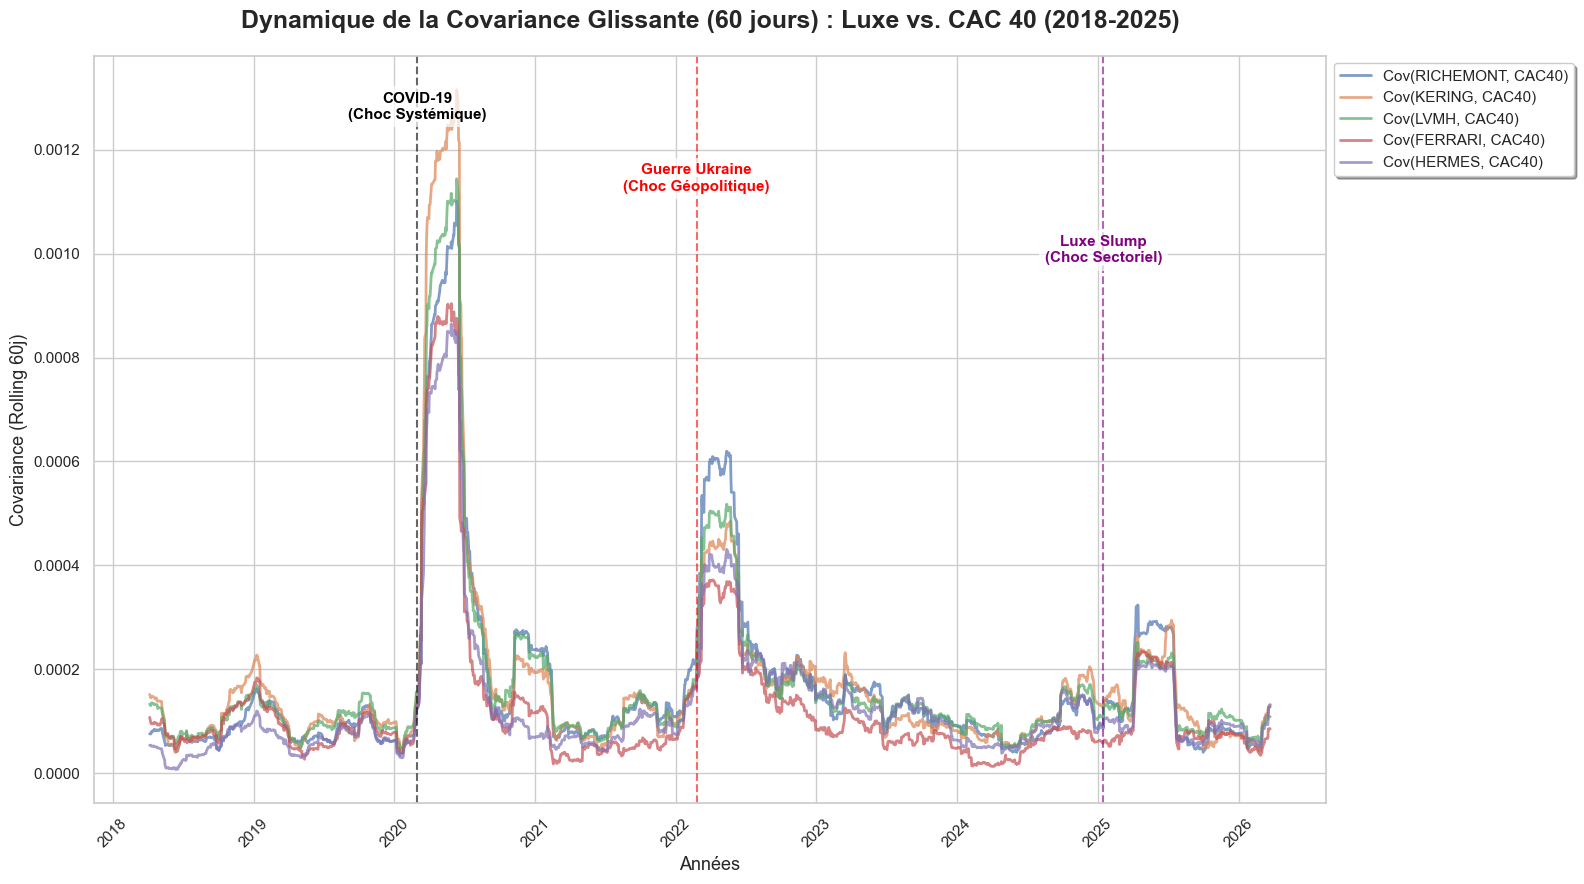

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# On configure le style pour qu'il soit propre et lisible
plt.figure(figsize=(16, 9))
sns.set_theme(style="whitegrid")

# 1. Calcul et tracé de la covariance glissante pour chaque entreprise
# On utilise une fenêtre de 60 jours pour bien lisser les tendances
entreprises = [c for c in df_returns.columns if c not in ['CAC40', 'VIX']]

for ent in entreprises:
    rolling_cov = df_returns[ent].rolling(window=60).cov(df_returns['CAC40']).dropna()
    plt.plot(rolling_cov.index, rolling_cov.values, label=f'Cov({ent}, CAC40)', alpha=0.7, linewidth=2)

# 2. Ajout des lignes verticales et des étiquettes pour les événements clés

# Événement 1 : COVID-19 (Mars 2020) - Le choc systémique
date_covid = pd.to_datetime('2020-03-01')
plt.axvline(date_covid, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
plt.text(date_covid, plt.ylim()[1] * 0.95, 'COVID-19\n(Choc Systémique)', 
         fontsize=11, fontweight='bold', color='black', ha='center', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Événement 2 : Guerre en Ukraine (Février 2022) - Le choc géopolitique
date_ukraine = pd.to_datetime('2022-02-24')
plt.axvline(date_ukraine, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
plt.text(date_ukraine, plt.ylim()[1] * 0.85, 'Guerre Ukraine\n(Choc Géopolitique)', 
         fontsize=11, fontweight='bold', color='red', ha='center', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Événement 3 : Ralentissement du Luxe (Début 2025) - Le choc sectoriel (Chine)
date_luxe_slump = pd.to_datetime('2025-01-15')
plt.axvline(date_luxe_slump, color='purple', linestyle='--', linewidth=1.5, alpha=0.6)
plt.text(date_luxe_slump, plt.ylim()[1] * 0.75, 'Luxe Slump\n(Choc Sectoriel)', 
         fontsize=11, fontweight='bold', color='purple', ha='center', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# 3. Réglages finaux pour un rendu professionnel
plt.title("Dynamique de la Covariance Glissante (60 jours) : Luxe vs. CAC 40 (2018-2025)", 
          fontsize=18, fontweight='bold', pad=20)
plt.ylabel("Covariance (Rolling 60j)", fontsize=13)
plt.xlabel("Années", fontsize=13)

# Amélioration de la légende
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=11, frameon=True, shadow=True)

# Formatage précis de l'axe des dates
import matplotlib.dates as mdates
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

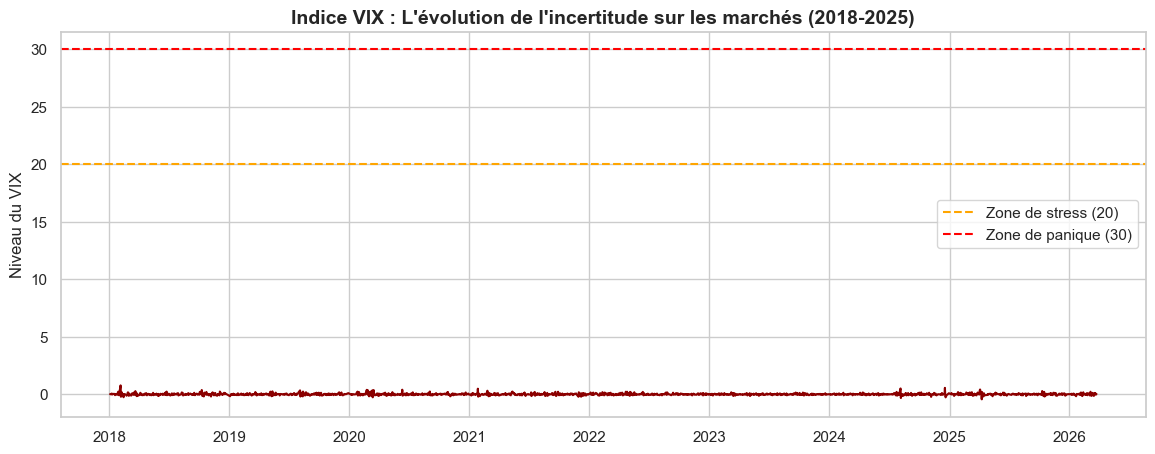

In [20]:
# Remplace 'df_returns' par le nom que TU as donné à ton tableau
df_vix_brut = df_returns['VIX'] 

# Relance ensuite le graphique
plt.figure(figsize=(14, 5))
plt.plot(df_vix_brut.index, df_vix_brut, color='darkred', linewidth=1.5)
plt.fill_between(df_vix_brut.index, df_vix_brut, color='red', alpha=0.1)

plt.title("Indice VIX : L'évolution de l'incertitude sur les marchés (2018-2025)", fontsize=14, fontweight='bold')
plt.ylabel("Niveau du VIX")
plt.axhline(20, color='orange', linestyle='--', label='Zone de stress (20)')
plt.axhline(30, color='red', linestyle='--', label='Zone de panique (30)')
plt.legend()
plt.show()

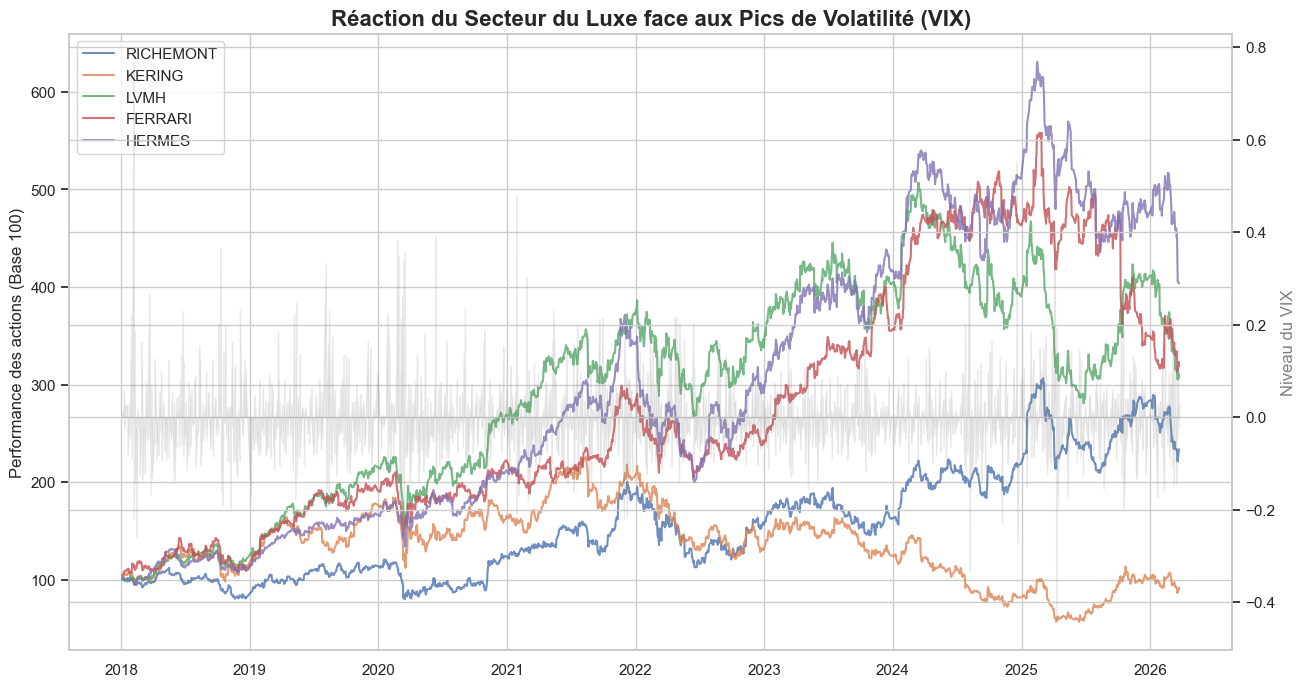

In [21]:
fig, ax1 = plt.subplots(figsize=(15, 8))

# Axe 1 : Toutes les entreprises du Luxe (Performance Base 100)
for col in df_cum_perf.columns:
    if col not in ['VIX', 'CAC40']:
        ax1.plot(df_cum_perf.index, df_cum_perf[col], label=col, alpha=0.8)

ax1.set_ylabel("Performance des actions (Base 100)", fontsize=12)
ax1.legend(loc='upper left')

# Axe 2 : Le VIX en arrière-plan
ax2 = ax1.twinx()
ax2.fill_between(df_vix_brut.index, df_vix_brut, color='gray', alpha=0.15, label='VIX (Peur)')
ax2.set_ylabel("Niveau du VIX", color='gray', fontsize=12)

plt.title("Réaction du Secteur du Luxe face aux Pics de Volatilité (VIX)", fontsize=16, fontweight='bold')
plt.show()